Up to this point we have not considered that all basis sets don't present linear dependencies or that they are handled elsewhere. However, since we are actually building a whole "independent" focused code, it is something that has to be dealt with. 

Let's start by recalling the problem: Some basis sets present linear dependent basis functions, i.e. some of the AO basis functions can be expressed as linear combinations of other basis functions. Considering that, recall that diagonalizing a linearly (or almost linearly dependent matrix) results in: 

In [1]:
from typing import Literal, Union

import numpy as np
from numpy.typing import NDArray

from py_mods.src.external.DIRAC_ME import build_S_V_W_T_from_h5, generate_primitive_KUSCFContext_from_h5
from py_mods.src.SCF.plot_utilities import plot_map
from py_mods.src.SCF_4c.CS_KU_SCF import CS_4c_KU_SCF

In [2]:
matrix = np.array([
    [1, 2, 3], 
    [4, 5, 6], 
    [2, 4, 6]]
)

e, w = np.linalg.eig(matrix)

print(f"Eigenvalues are: {e}")

Eigenvalues are: [1.17445626e+01 4.70060135e-15 2.55437353e-01]


Where we see that due to linear dependency, an eigenvalue is (numerical) zero. 

---

# The relevance of linear dependencies in the SCF 
Recalling the SCF procedure, we want to solve the eigenvalue problem:

$$
F_{MO}C_{MO}=S_{MO}C_{MO}\varepsilon
$$

The standard procedure is to first build the transformation matrix $X$ such that:

$$
X^T S_{AO} X = I
$$ 

And by multipling $F_MO$ by $X$ we can obtain the orthogonalized Fock matrix:

$$
F_{orth} = X^T F_{AO} X
$$

And then solve directly:

$$
F_{orth} C_{orth} = C_{orth} \varepsilon
$$

The issue that arises from linear dependencies is that the transfomation matrix can be defined either symmetrycally:

$$
X_{symm} = U s^{-1/2} U^T
$$

Or cannonically:

$$
X_{canon} = U s^{-1/2}
$$

However, since both of these methods require the inverse of the square root of the eigenvalues, they can be numerically unstable when the eigenvalues are small or close to zero. The solution is to directly discard the eigenvectors associated with the small eigenvalues, which correspond to the linearly dependent basis functions. As a consequence, there will be more rows than columns. 

Lets consider the sligtly modified function:

In [3]:
def transformation_matrix(
    S: Union[NDArray[np.complex128], NDArray[np.float64]],
    method: Literal["canonical", "symmetric"] = "symmetric",
    verbose: bool = False,
    remove_lindep: bool = True,
    lindep_threshold: float = 1e-6,
) -> NDArray[np.float64]:
    """
    Calculate basis transformation matrix X.
    """
    assert method in [
        "canonical",
        "symmetric",
    ], "method must be 'canonical' or 'symmetric'"

    s, U = np.linalg.eigh(S)

    if remove_lindep:
        last_idx = 0

        for idx, eval in enumerate(s):
            last_idx = idx
            if eval > lindep_threshold:
                break

        if last_idx > 0:
            if method == "symmetric" and verbose:
                print(
                    "Removing linear dependencies implies canonical orthogonalization."
                )

            print(
                f"Removing {last_idx} linear dependencies with eigenvalues below {lindep_threshold:.2e} (largest removed eigenvalue: {s[last_idx-1]:.2e})"
            )

            U_truncated = U[:, last_idx:]
            s_truncated = s[last_idx:]

            s_root = np.diag(1.0 / np.sqrt(s_truncated))

            # This is no longer N x N, but rectangular NxM where M < N
            X = U_truncated @ s_root
            return X

    # Regular no lindep removal
    s_root = np.diag(1.0 / np.sqrt(s))

    if method == "symmetric":
        # U * s^{-1/2} * U^T
        X = U @ s_root @ U.conj().T
    elif method == "canonical":
        X = U @ s_root

    if verbose:
        transformed = X.conj().T @ S @ X
        print("Transformed S (should be Identity):\n", np.round(transformed, 10))

    return X

The removal of colums leads to a $N\times M$ rectangular matrix, where $M < N$. Therefore, by applying the transformation to a $N\times N$ AO matrix: 

$$
O_{M \times M}^{MO} = X^{\dagger}_{M\times N} O_{N\times N}^{AO} X_{N\times M} 
$$

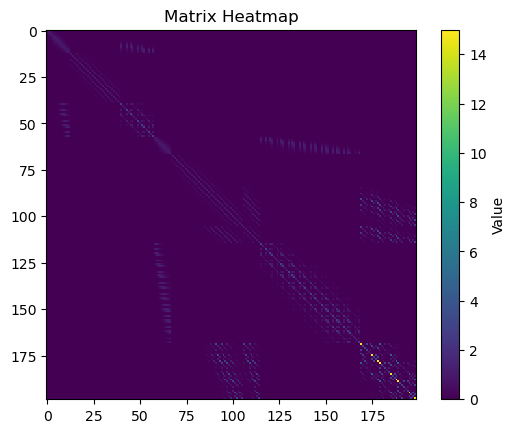

In [4]:
S, V, W, T = build_S_V_W_T_from_h5('../4c-scf/data/Mg_checkpoint.h5')
S_full = S[:len(S)//2,:len(S)//2]
V = V[:len(V)//2,:len(V)//2]
W = W[:len(W)//2,:len(W)//2]
T = T[:len(T)//2,:len(T)//2]

plot_map(S_full)

Removing 3 linear dependencies with eigenvalues below 1.00e-06 (largest removed eigenvalue: 7.31e-10)


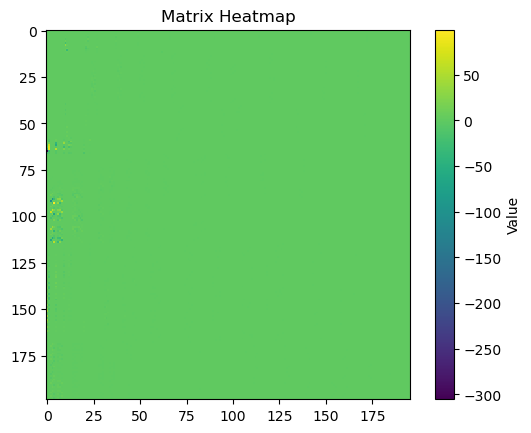

In [5]:
X = transformation_matrix(S_full, remove_lindep=True)
X.shape
plot_map(X)

In [6]:
S_orth = (X.conj().T @ S_full @ X)
print(f"Original dimension of S: {S_full.shape}")
print(f"Dimension after removal of linear dependencies:{S_orth.shape}")

Original dimension of S: (199, 199)
Dimension after removal of linear dependencies:(196, 196)


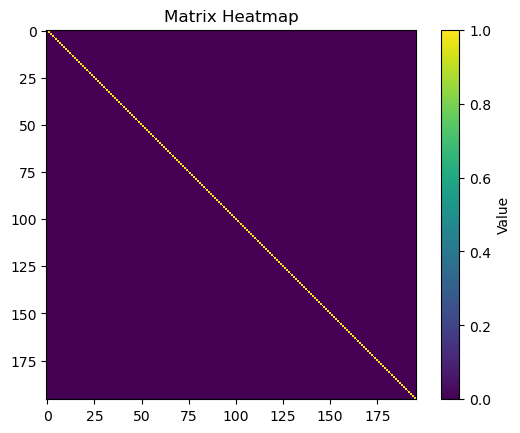

In [7]:
plot_map(S_orth)

In [8]:
(X @ S_orth @ X.conj().T).shape

(199, 199)

And this can all be applied to the rest of matrices that get transformed to the orthogonal basis representation. 

---

# Working with the reduced MO basis
Since the size of the AO basis and of the MO basis is not the same anymore, we need to adapt all the code that relies on the MO basis. Out of the box, since everything is performed based on einsums, the most worrying thing is the mismatch between the occupation vector and the MO basis. In the formation of the density matrix, we have a contraction:

$$
P_{\mu \nu}^{MO} = \sum_{i} C_{\mu i}^{MO} C_{\nu i}^{MO} n_i
$$

Since $C_{\mu\nu}^{MO}$ presents dimensions of $XC_{\lambda \sigma}^{AO}$, it will be $M \times M$, while the occupation vector was built originally at definition with size $N$. Therefore we need somehow to determine the number of removed lindep and assess if they are removed from the small or large component, to align the occupation vector with the MO basis.


First, we can determine the number of linear dependencies as the difference between the number of rows and colums in the transformation matrix: 

$$ 
N_{lin} = N - M
$$

However, we dont know direcly if these belong to the small or large components. Therefore, we apply the transformation to F: 

$$
F_{MO} = X^T F_{AO} X
$$

And diagonalize $F_MO$, that yields $M$ eigenvalues. By determining the number of electronic and positronic solutions, due to positronic solutions being directly related to the small component, we can determine how many linear dependencies belong to the small and large components: 

$$
N_{lin}^{large} = N_{elec} - N_{pos}
$$

$$
N_{lin}^{small} = N_{lin} - N_{lin}^{large}
$$

And then we can directly remove the corresponding number of elements from the occupation vector by shortening the small component vector by the number of linear dependencies in the small component, and the large component vector by removing virtual orbitals. 

As a consequence, we obtain then the occupation vector with the same size as the MO basis, but aligned with the correct basis functions.

This process is performed at the beginning of the SCF procedure, and then the occupation vector is used as normal in the rest of the code. The code used to perform this procedure is:

```python
n_lindep = np.abs(
    ext_ctx.X.shape[0] - ext_ctx.X.shape[1]
)  # The difference between row and column size is the number of lindeps

if n_lindep > 0: 
    H_core = ctx.V + ctx.T + ctx.W
    F_0 = ext_ctx.X.conj().T @ H_core.astype(np.complex128) @ ext_ctx.X
    e_0 = np.linalg.eigvals(F_0)
    n_pos_ener_eigvals = sum([1 for ev in e_0 if ev > -2000])
    n_neg_ener_eigvals = sum([1 for ev in e_0 if ev <= -2000])
    old_nL = ctx.nL
    old_nS = ctx.nS

    ctx.nL = n_pos_ener_eigvals // 2
    ctx.nS = n_neg_ener_eigvals // 2

    if isinstance(ctx.occ, np.ndarray):
        if len(ctx.occ) == 2 * (old_nL + old_nS):
            old_lc_occ = ctx.occ[2 * old_nS :]
        else:
            old_lc_occ = ctx.occ
            
        lc_occ = old_lc_occ[:n_pos_ener_eigvals]
        new_occ = np.zeros(2 * (ctx.nL + ctx.nS), dtype=np.int32)
        length = min(len(lc_occ), 2 * ctx.nL)
        new_occ[2 * ctx.nS : 2 * ctx.nS + length] = lc_occ[:length]
        ctx.occ = new_occ
```

In [ ]:
Ar_cxt = generate_primitive_KUSCFContext_from_h5(
    "../4c-scf/data/Ar_cc_pvtz.h5",
    total_charge=0,
    threshold=1e-8,
    integral_symmetry=8,
)

In [10]:
lindep_res = CS_4c_KU_SCF(Ar_cxt)

Removing 8 linear dependencies with eigenvalues below 1.00e-06 (largest removed eigenvalue: 1.11e-15)
Linear dependencies removed: LC = 8. SC = 0
Basis resize: LC = 86 -> 78, SC = 198 -> 198. Total size: 284 -> 276.
-------------------------------------------------------------------------------------------------------------------------------------
|   Iter   |                    E_iter                     |                    Delta_e                    |       norm(e_i)        |
-------------------------------------------------------------------------------------------------------------------------------------
|    1     |    0.0000000000000000+0.0000000000000000j     |    0.0000000000000000+0.0000000000000000j     |       0.0000E+00       |
|    2     |   -468.6946341033399221+0.0000000000000034j   |   -468.6946341033399221+0.0000000000000034j   |       6.1873E+01       |
|    3     |   -512.0081525934950832+0.0000000000000011j   |   -43.3135184901551611-0.0000000000000023j    |      

In [11]:
print(
    f"Energy matches with reference : {abs(lindep_res.E_SCF - -528.67091582200760) < 1e-8}"
)

print()

Energy matches with reference : True

